In [1]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "png"

# Example 6.2 : Random Walk

In [2]:
def tabularTD0RW(maxEpisodes, vInit, policy, alpha=0.1):
    V = vInit.copy()
    learningCurve = np.empty((maxEpisodes, 5))

    episode = 0
    while episode < maxEpisodes:
        terminal = False
        currentState = 2
        while not terminal:
            currentAction = np.random.choice([-1, 1], p=policy[currentState])
            if currentState == 4 and currentAction == 1:
                terminal = True
                V[currentState] += alpha * (1 - V[currentState])
            elif currentState == 0 and currentAction == -1:
                terminal = True
                V[currentState] -= alpha * V[currentState]
            else:
                V[currentState] += alpha * (V[currentState + currentAction] - V[currentState])
                currentState = currentState + currentAction

        learningCurve[episode] = V.copy()
        episode += 1
    return learningCurve

In [3]:
learningCurveTDRW = tabularTD0RW(100, 0.5 * np.ones(5), 0.5 * np.ones((5, 2)), alpha=0.1)

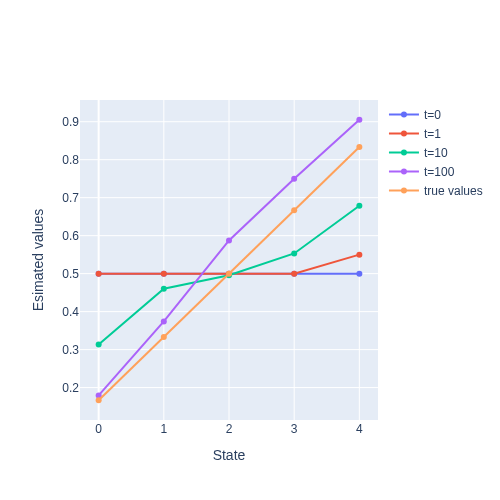

In [4]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=0.5 * np.ones(5), name="t=0"))
fig.add_trace(go.Scatter(y=learningCurveTDRW[0], name="t=1"))
fig.add_trace(go.Scatter(y=learningCurveTDRW[9], name="t=10"))
fig.add_trace(go.Scatter(y=learningCurveTDRW[99], name="t=100"))
fig.add_trace(go.Scatter(y=np.arange(1, 6) / 6, name="true values"))
fig.update_layout(width=500, xaxis_title="State", yaxis_title="Esimated values")
fig.show()

In [5]:
def alphaMCPRW(maxEpisodes, vInit, policy, alpha=0.1):
    V = vInit.copy()
    learningCurve = np.empty((maxEpisodes, 5))

    episode = 0
    while episode < maxEpisodes:
        terminal = False
        currentState = 2
        trajectory = []
        while not terminal:
            trajectory.append(currentState)
            currentAction = np.random.choice([-1, 1], p=policy[currentState])
            if currentState == 4 and currentAction == 1:
                terminal = True
                reward = 1
            elif currentState == 0 and currentAction == -1:
                terminal = True
                reward = 0
            else:
                currentState = currentState + currentAction

        for state in trajectory[::-1]:
            V[state] += alpha * (reward - V[state])

        learningCurve[episode] = V.copy()
        episode += 1
    return learningCurve    

In [6]:
alphas = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.15]
alphaTDCurvesRW = []
alphaMCCurvesRW = []
trueValue = np.arange(1, 6) / 6

for alpha in alphas:
    errorsTDRW = []
    errorsMCRW = []
    for run in range(100):
        runLearningCurveTDRW = tabularTD0RW(1000, 0.5 * np.ones(5), 0.5 * np.ones((5, 2)), alpha=alpha)
        errorsTDRW.append(np.mean(np.sqrt((runLearningCurveTDRW - trueValue) ** 2), axis=1))
        runLearningCurveMCRW = alphaMCPRW(1000, 0.5 * np.ones(5), 0.5 * np.ones((5, 2)), alpha=alpha)
        errorsMCRW.append(np.mean(np.sqrt((runLearningCurveMCRW - trueValue) ** 2), axis=1))
    alphaTDCurvesRW.append(np.mean(np.stack(errorsTDRW), axis=0))
    alphaMCCurvesRW.append(np.mean(np.stack(errorsMCRW), axis=0))

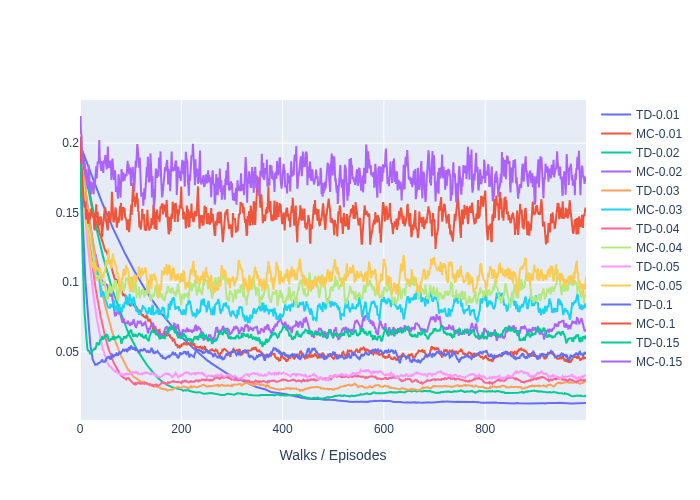

In [7]:
fig = go.Figure()
for alpha in range(len(alphas)):
    fig.add_trace(go.Scatter(y=alphaTDCurvesRW[alpha], name=f"TD-{alphas[alpha]}"))
    fig.add_trace(go.Scatter(y=alphaMCCurvesRW[alpha], name=f"MC-{alphas[alpha]}"))

fig.update_layout(width=700, xaxis_title="Walks / Episodes")
fig.show()

## Alternative initializatio of $q_{init}$

In [8]:
alphas = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.15]
alphaTDCurvesRW = []
trueValue = np.arange(1, 6) / 6

for alpha in alphas:
    errorsTDRW = []
    for run in range(100):
        runLearningCurveTDRW = tabularTD0RW(1000, np.ones(5), 0.5 * np.ones((5, 2)), alpha=alpha)
        errorsTDRW.append(np.mean(np.sqrt((runLearningCurveTDRW - trueValue) ** 2), axis=1))
    alphaTDCurvesRW.append(np.mean(np.stack(errorsTDRW), axis=0))


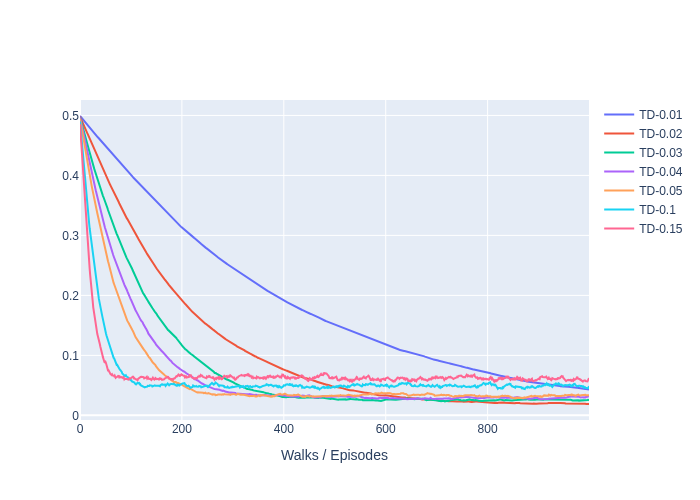

In [9]:
fig = go.Figure()
for alpha in range(len(alphas)):
    fig.add_trace(go.Scatter(y=alphaTDCurvesRW[alpha], name=f"TD-{alphas[alpha]}"))

fig.update_layout(width=700, xaxis_title="Walks / Episodes")
fig.show()

# Example 6.3 : Random walk under batch updating

In [10]:
def sampleRWTrajectory(policy):
    trajectory = []
    currentState = 2
    terminal = False
    while not terminal:
        trajectory.append(currentState)
        currentAction = np.random.choice([-1, 1], p=policy[currentState])
        if currentState == 4 and currentAction == 1:
            terminal = True
        elif currentState == 0 and currentAction == -1:
            terminal = True
        else:
            currentState = currentState + currentAction
        
    return trajectory
    

In [11]:
def batchUpdating(nRuns, nEpisodes, policy, vInit, alpha=0.001, theta=0.001):
    errorsBUTDRW = []
    errorsBUMCRW = []

    for run in range(nRuns):
        learningCurveUBTD = np.empty((nEpisodes, 5))
        learningCurveUBMC = np.empty((nEpisodes, 5))
        VTD = vInit.copy()
        VMC = vInit.copy()
        episodes = []
        for episode in range(nEpisodes):
            episodes.append(sampleRWTrajectory(policy))
            
            convergedTD = False
            convergedMC = False
            while not (convergedTD and convergedMC):
                errorTD = np.zeros(5)
                errorMC = np.zeros(5)

                for previousEpisode in episodes:
                    reward = previousEpisode[-1] == 4
                    for step in range(len(previousEpisode) - 1):
                        if not convergedTD:
                            errorTD[previousEpisode[step]] += alpha * (VTD[previousEpisode[step + 1]] - VTD[previousEpisode[step]])
                        if not convergedMC:
                            errorMC[previousEpisode[step]] += alpha * (reward - VMC[previousEpisode[step]])

                    if not convergedTD:
                        errorTD[previousEpisode[-1]] += alpha * (reward - VTD[previousEpisode[-1]])
                    if not convergedMC:
                        errorMC[previousEpisode[-1]] += alpha * (reward - VMC[previousEpisode[-1]])

                if not convergedTD:
                    VTD += errorTD
                    convergedTD = np.sum(np.abs(errorTD)) <= theta

                if not convergedMC:
                    VMC += errorMC
                    convergedMC = np.sum(np.abs(errorMC)) <= theta
            
            learningCurveUBTD[episode] = VTD.copy()
            learningCurveUBMC[episode] = VMC.copy()

        errorsBUTDRW.append(np.mean(np.sqrt((learningCurveUBTD - trueValue) ** 2), axis=1))
        errorsBUMCRW.append(np.mean(np.sqrt((learningCurveUBMC - trueValue) ** 2), axis=1))

    avgErrorTDRW = np.mean(np.stack(errorsBUTDRW), axis=0)
    avgErrorMCRW = np.mean(np.stack(errorsBUMCRW), axis=0)

    return avgErrorTDRW, avgErrorMCRW


In [12]:
avgErrorBUTDRW, avgErrorBUMCRW = batchUpdating(100, 100, 0.5 * np.ones((5, 2)), np.zeros(5), alpha=0.001, theta=0.001)

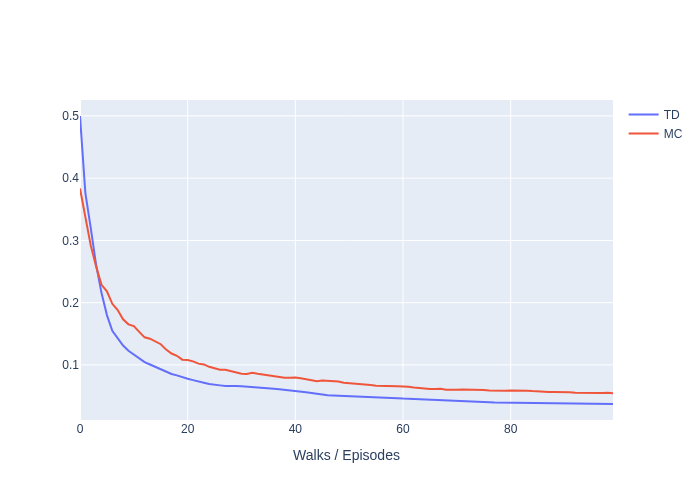

In [13]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=avgErrorBUTDRW, name="TD"))
fig.add_trace(go.Scatter(y=avgErrorBUMCRW, name="MC"))

fig.update_layout(width=700, xaxis_title="Walks / Episodes")
fig.show()

# Example 6.5 : Windy Gridworld

In [14]:
gridWind = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]
maxRowWGW = 7
maxColWGW = 10
startPosWGW = (3, 0)
endPosWGW = (3, 7)
UP, DOWN, RIGHT, LEFT, UPRIGHT, UPLEFT, DOWNRIGHT, DOWNLEFT, STILL = 0, 1, 2, 3, 4, 5, 6, 7, 8

In [15]:
def deriveNextState(currentPosition, action, maxRow, maxCol):
    row, col = currentPosition
    if action == UP:
        nextRow = row - 1
        nextCol = col
    elif action == DOWN:
        nextRow = row + 1
        nextCol = col
    elif action == RIGHT:
        nextRow = row
        nextCol = col + 1
    elif action == LEFT:
        nextRow = row
        nextCol = col - 1
    elif action == UPRIGHT:
        nextRow = row - 1
        nextCol = col + 1
    elif action == UPLEFT:
        nextRow = row - 1
        nextCol = col - 1
    elif action == DOWNRIGHT:
        nextRow = row + 1
        nextCol = col + 1
    elif action == DOWNLEFT:
        nextRow = row + 1
        nextCol = col - 1
    elif action == STILL:
        nextRow = row
        nextCol = col

    return min(max(int(nextRow), 0), maxRow - 1), min(max(int(nextCol), 0), maxCol - 1)

In [16]:
def lenTrajGW(policy, maxStep, startPos, endPos, maxRow, maxCol, wind=True, stochasticWind=False):
    currentState = startPos

    t = 0
    while t < maxStep:
        t += 1
        windValue = 0
        if wind:
            windValue = gridWind[currentState[1]] + np.random.choice([-1, 0, 1]) * stochasticWind * (gridWind[currentState[1]] != 0)

        nextState = deriveNextState((currentState[0] - windValue, currentState[1]), policy[*currentState], maxRow, maxCol)
        if nextState == endPos:
            break
        currentState = nextState
    return t

In [17]:
def sarsaWGW(nEpisodes, qInit, availableActions=[UP, DOWN, RIGHT, LEFT], stochasticWind=False, epsilon=0.1, alpha=0.5):
    Q = qInit.copy()
    nTimeSteps = np.zeros(nEpisodes)
    lenTrajs = np.zeros(nEpisodes)

    for episode in range(nEpisodes):
        currentState = startPosWGW
        if np.random.random() < epsilon:
            currentAction = np.random.choice(availableActions)
        else:
            currentAction = np.random.choice([action for action in availableActions if Q[*currentState, action] == np.max(Q[*currentState])])

        terminal = False
        t = 0
        while not terminal:
            nextState = deriveNextState((currentState[0] - (gridWind[currentState[1]] + np.random.choice([-1, 0, 1]) * stochasticWind * (gridWind[currentState[1]] != 0)), currentState[1]), currentAction, maxRowWGW, maxColWGW)
            t += 1

            if nextState == endPosWGW:
                terminal = True
                Q[*currentState, currentAction] += alpha * (-1 - Q[*currentState, currentAction])
                break

            if np.random.random() < epsilon:
                nextAction = np.random.choice(availableActions)
            else:
                nextAction = np.random.choice([action for action in availableActions if Q[*nextState, action] == np.max(Q[*nextState])])

            Q[*currentState, currentAction] += alpha * (-1 + Q[*nextState, nextAction] - Q[*currentState, currentAction])
            currentState = nextState
            currentAction = nextAction

        nTimeSteps[episode] = t
        lenTrajs[episode] = np.mean([lenTrajGW(np.argmax(Q, axis=2), 100, startPosWGW, endPosWGW, maxRowWGW, maxColWGW, wind=True, stochasticWind=stochasticWind) for _ in range(50)])
        
    return Q, nTimeSteps, lenTrajs

In [18]:
nEpisodesWGW = 200
qInitWGW = np.zeros((maxRowWGW, maxColWGW, 4))
qStarWGW, nTimeStepsWGW, lenTrajsWGW = sarsaWGW(nEpisodesWGW, qInitWGW, epsilon=0.01, alpha=0.5)

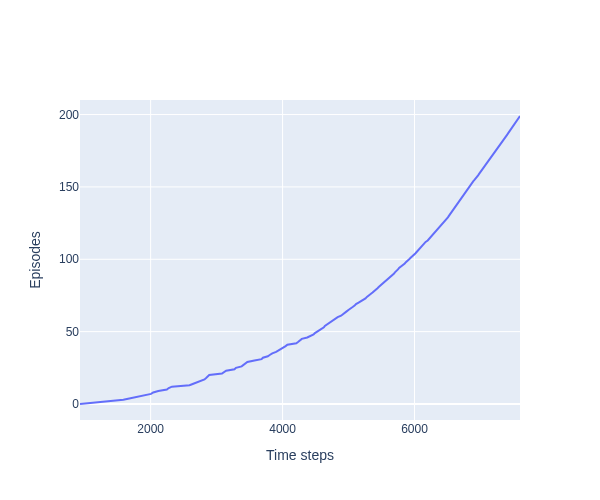

In [19]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.cumsum(nTimeStepsWGW), y=np.arange(nEpisodesWGW)))
fig.update_layout(width=600, xaxis_title="Time steps", yaxis_title="Episodes")
fig.show()

In [20]:
def plotWGWSolution(policy, stochasticWind=False):
    fig = go.Figure()

    for row in range(maxRowWGW - 1, -1, -1):
        for col in range(maxColWGW):
            fig.add_shape(type="rect", x0=col - 0.5, y0=row - 0.5, x1=col + 0.5, y1=row + 0.5, line=dict(color="black", width=1))
            if (row, col) == startPosWGW:
                fig.add_annotation(y=row, x=col - 0.2, text="S", showarrow=False, font=dict(size=13))
            if (row, col) == endPosWGW:
                fig.add_annotation(y=row, x=col - 0.2, text="G", showarrow=False, font=dict(size=13))

    y = []
    x = []
    intendedYs = []
    intendedXs = []
    currentPos = startPosWGW
    currentIntendedPos = startPosWGW
    terminal = False
    while not terminal:
        y.append(maxRowWGW - 1 - currentPos[0])
        x.append(currentPos[1])
        intendedYs.append(maxRowWGW - 1 - currentIntendedPos[0])
        intendedYs.append(maxRowWGW - 1 - currentPos[0])
        intendedXs.append(currentIntendedPos[1])
        intendedXs.append(currentPos[1])

        currentIntendedPos = deriveNextState(currentPos, policy[*currentPos], maxRowWGW, maxColWGW)
        fig.add_trace(go.Scatter(x=[currentPos[1], currentIntendedPos[1]], y=[maxRowWGW - 1 - currentPos[0], maxRowWGW - 1 - currentIntendedPos[0]], marker=dict(size=8, symbol="arrow", angleref="previous", color="red"), showlegend=False))
        wind = gridWind[currentPos[1]] + np.random.choice([-1, 0, 1]) * stochasticWind * (gridWind[currentPos[1]] != 0)
        currentPos = deriveNextState((currentPos[0] - wind, currentPos[1]), policy[*currentPos], maxRowWGW, maxColWGW)

        if currentPos == endPosWGW:
            y.append(maxRowWGW - 1 - endPosWGW[0])
            x.append(endPosWGW[1])
            terminal = True
            break

    fig.add_trace(go.Scatter(x=x, y=np.array(y), marker=dict(size=10, symbol="arrow", angleref="previous"), showlegend=False))
    fig.update_layout(plot_bgcolor="white", width=600)
    fig.update_xaxes(tickvals=np.arange(maxColWGW),ticktext=gridWind)
    fig.update_yaxes(scaleanchor="x", tickvals=np.arange(maxRowWGW), ticktext=[""] * maxRowWGW)

    fig.show()

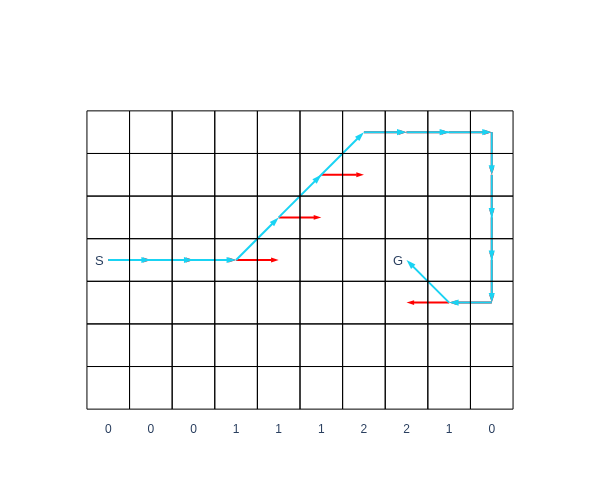

In [21]:
plotWGWSolution(np.argmax(qStarWGW, axis=2))

# Exercice 6.9 : Windy Gridworld with King's Moves

## Without the STILL action

In [22]:
nEpisodesKWGW = 200
qInitKWGW = np.zeros((maxRowWGW, maxColWGW, 8))
qStarKWGW, nTimeStepsKWGW, lenTrajsKWGW = sarsaWGW(nEpisodesKWGW, qInitKWGW, availableActions=[UP, DOWN, RIGHT, LEFT, UPRIGHT, UPLEFT, DOWNRIGHT, DOWNLEFT], epsilon=0.01, alpha=0.5)

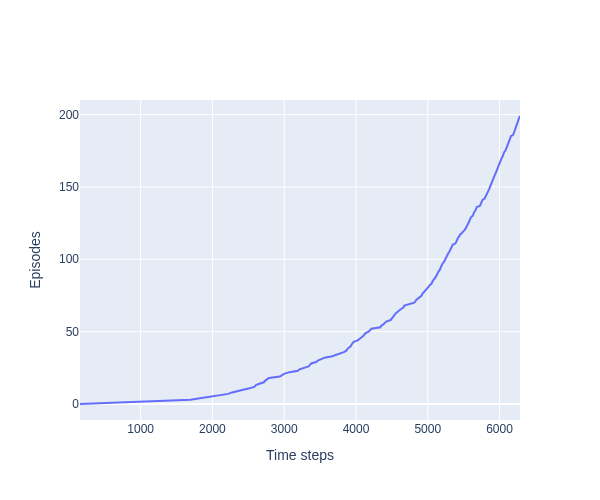

In [23]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.cumsum(nTimeStepsKWGW), y=np.arange(nEpisodesKWGW)))
fig.update_layout(width=600, xaxis_title="Time steps", yaxis_title="Episodes")
fig.show()

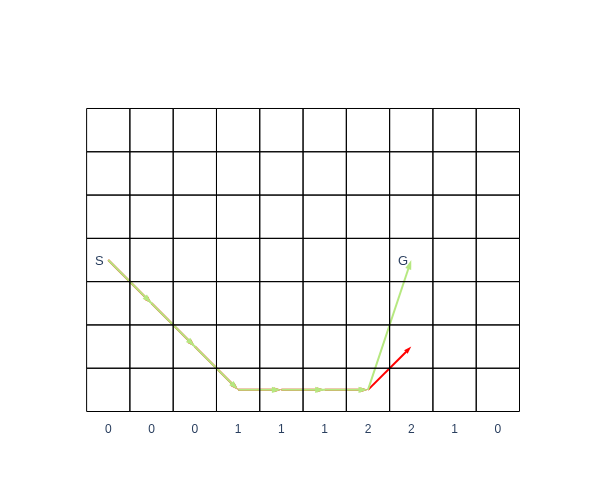

In [24]:
plotWGWSolution(np.argmax(qStarKWGW, axis=2))

## With the STILL action

In [25]:
nEpisodesKWGW = 200
qInitKWGW = np.zeros((7, 10, 9))
qStarKWGW, nTimeStepsKWGW, lenTrajsKWGW = sarsaWGW(nEpisodesKWGW, qInitKWGW, availableActions=[UP, DOWN, RIGHT, LEFT, UPRIGHT, UPLEFT, DOWNRIGHT, DOWNLEFT, STILL], epsilon=0.01, alpha=0.5)

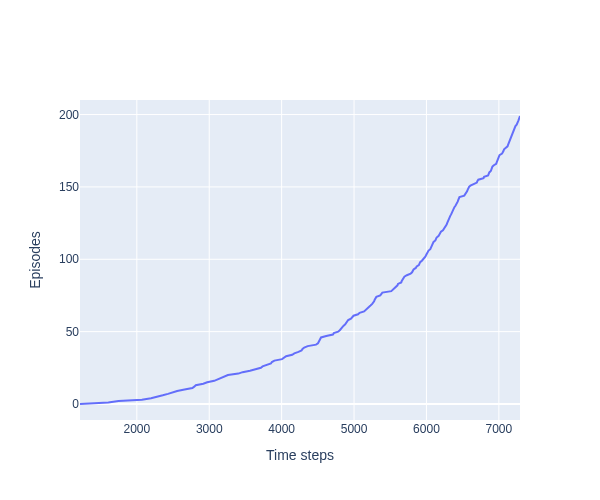

In [26]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.cumsum(nTimeStepsKWGW), y=np.arange(nEpisodesKWGW)))
fig.update_layout(width=600, xaxis_title="Time steps", yaxis_title="Episodes")
fig.show()

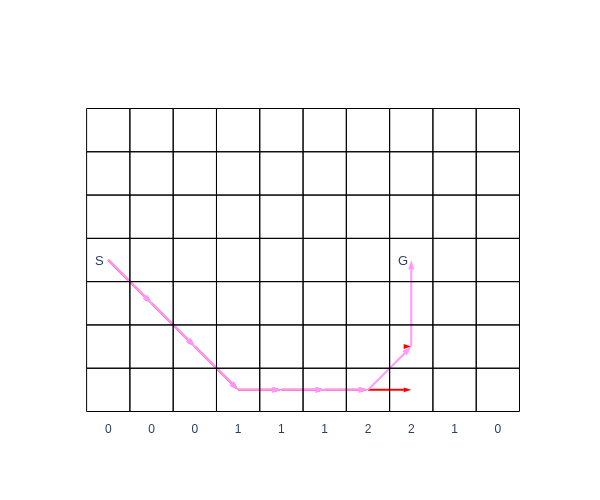

In [27]:
plotWGWSolution(np.argmax(qStarKWGW, axis=2))

# Exercise 6.10 : Stochastic Wind 

In [28]:
nEpisodesKSWGW = 2000
qInitKSWGW = np.zeros((maxRowWGW, maxColWGW, 8))
qStarKSWGW, nTimeStepsKSWGW, lenTrajsKSWGW = sarsaWGW(nEpisodesKSWGW, qInitKSWGW, availableActions=[UP, DOWN, RIGHT, LEFT, UPRIGHT, UPLEFT, DOWNRIGHT, DOWNLEFT], stochasticWind=True, epsilon=0.01, alpha=0.5)

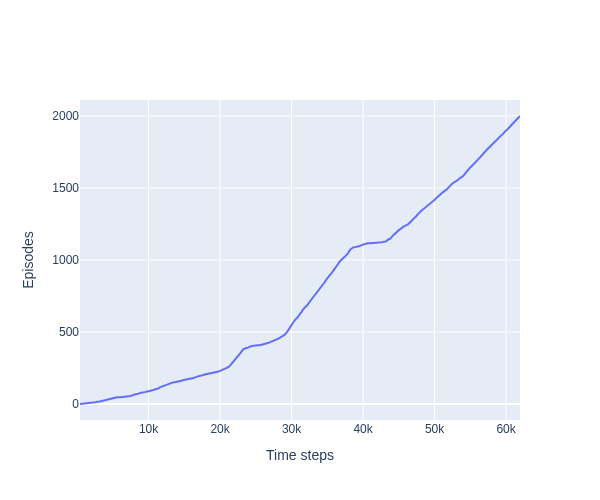

In [29]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.cumsum(nTimeStepsKSWGW), y=np.arange(nEpisodesKSWGW)))
fig.update_layout(width=600, xaxis_title="Time steps", yaxis_title="Episodes")
fig.show()

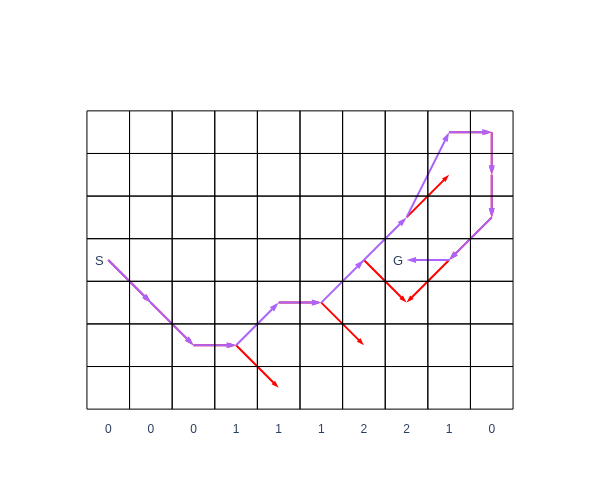

In [30]:
plotWGWSolution(np.argmax(qStarKSWGW, axis=2), stochasticWind=True)

# Example 6.6 : Cliff Walking

In [31]:
maxRowCW = 4
maxColCW = 12
cliff = np.zeros((maxRowCW, maxColCW), dtype=bool)
cliff[-1, 1:11] = True
startPosCW = (3, 0)
endPosCW = (3, 11)

In [32]:
def TDCW(nEpisodes, qInit, availableActions=[UP, DOWN, RIGHT, LEFT], epsilon=0.1, alpha=0.5, sarsa=True):
    Q = qInit.copy()
    rewardSum = np.zeros(nEpisodes)
    
    for episode in range(nEpisodes):
        currentState = startPosCW
        if np.random.random() < epsilon:
            currentAction = np.random.choice(availableActions)
        else:
            currentAction = np.random.choice([action for action in availableActions if Q[*currentState, action] == np.max(Q[*currentState])])

        terminal = False
        t = 0
        while not terminal:
            nextState = deriveNextState(currentState, currentAction, maxRowCW, maxColCW)
            t += 1

            if nextState == endPosCW:
                terminal = True
                rewardSum[episode] -= 1
                Q[*currentState, currentAction] += alpha * (-1 - Q[*currentState, currentAction])
                break

            reward = - 1
            if cliff[*nextState]:
                reward -= 99
                nextState = startPosCW

            if sarsa and np.random.random() < epsilon:
                nextAction = np.random.choice(availableActions)
            else:
                nextAction = np.random.choice([action for action in availableActions if Q[*nextState, action] == np.max(Q[*nextState])])

            Q[*currentState, currentAction] += alpha * (reward + Q[*nextState, nextAction] - Q[*currentState, currentAction])
            rewardSum[episode] += reward
            currentState = nextState
            currentAction = nextAction
            if not sarsa:
                if np.random.random() < epsilon:
                    currentAction = np.random.choice(availableActions)
                else:
                    currentAction = np.random.choice([action for action in availableActions if Q[*currentState, action] == np.max(Q[*currentState])])
        
    return Q, rewardSum

In [33]:
nEpisodesCW = 500
qInitCW = np.zeros((maxRowCW, maxColCW, 4))

In [34]:
rewardSumsSARSACW = []
rewardSumsQlearningCW = []

for experiment in range(1000):
    rewardSumsSARSACW.append(TDCW(nEpisodesCW, qInitCW, epsilon=0.1, alpha=0.5)[1])
    rewardSumsQlearningCW.append(TDCW(nEpisodesCW, qInitCW, epsilon=0.1, alpha=0.5, sarsa=False)[1])

avgRewardSumSARSACW = np.mean(rewardSumsSARSACW, axis=0)
avgRewardSumQlearningCW = np.mean(rewardSumsQlearningCW, axis=0)

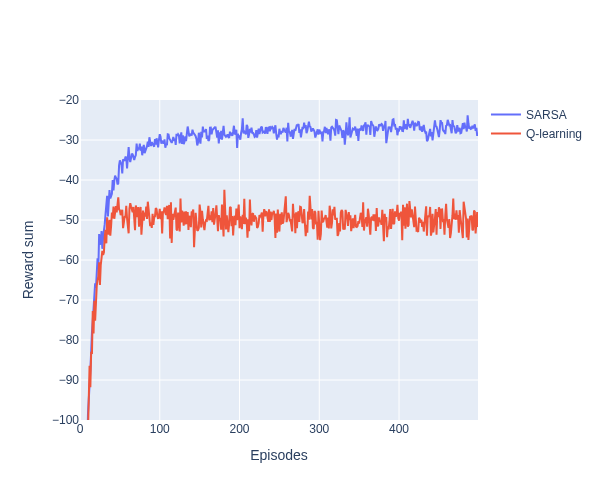

In [35]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=avgRewardSumSARSACW, name="SARSA"))
fig.add_trace(go.Scatter(y=avgRewardSumQlearningCW, name="Q-learning"))
fig.update_yaxes(range=[-100, -20])
fig.update_layout(xaxis_title="Episodes", yaxis_title="Reward sum", width=600)

## Interim and asymptotic perfromance of TD control methods

In [36]:
def expectedSARSACW(nEpisodes, qInit, availableActions=[UP, DOWN, RIGHT, LEFT], epsilon=0.1, alpha=0.5):
    Q = qInit.copy()
    rewardSum = np.zeros(nEpisodes)

    for episode in range(nEpisodes):
        currentState = startPosCW
        if np.random.random() < epsilon:
            currentAction = np.random.choice(availableActions)
        else:
            currentAction = np.random.choice([action for action in availableActions if Q[*currentState, action] == np.max(Q[*currentState])])

        terminal = False
        t = 0
        while not terminal:
            nextState = deriveNextState(currentState, currentAction, maxRowCW, maxColCW)
            t += 1

            if nextState == endPosCW:
                terminal = True
                rewardSum[episode] -= 1
                Q[*currentState, currentAction] += alpha * (-1 - Q[*currentState, currentAction])
                break

            reward = - 1
            if cliff[*nextState]:
                reward -= 99
                nextState = startPosCW

            target = epsilon * np.ones(len(availableActions)) / len(availableActions)
            maxQ = np.max(Q[*nextState])
            greedyActions = []
            for index, action in enumerate(availableActions):
                if Q[*nextState, action] == maxQ:
                    greedyActions.append(index)

            target[greedyActions] += (1 - epsilon) / len(greedyActions)
            assert(np.sum(target) == 1)


            Q[*currentState, currentAction] += alpha * (reward + np.sum(target * Q[*nextState, :]) - Q[*currentState, currentAction])
            rewardSum[episode] += reward
            currentState = nextState
            if np.random.random() < epsilon:
                currentAction = np.random.choice(availableActions)
            else:
                currentAction = np.random.choice([action for action in availableActions if Q[*currentState, action] == np.max(Q[*currentState])])
        
    return Q, rewardSum

In [ ]:
nEpisodesInterim = 100
nRunsInterim = 50000
nEpisodesAsymptotic = 100000
nRunAsymptotic = 10

alphas = 0.1 * np.arange(1, 11)
sarsaInterimCW = []
sarsaAsymptoticCW = []
qLearningInterimCW = []
qLearningAsymptoticCW = []
expectedSarsaInterimCW = []
expectedSarsaAsymptoticCW = []

for alpha in alphas:
    alphaSarsaAsymptotic = []
    alphaQlearningAsymptotic = []
    alphaExpectedSarsaAsymptotic = []
    for run in range(nRunAsymptotic):
        qSarsa, rewardSumSarsa = TDCW(nEpisodesAsymptotic, qInitCW, epsilon=0.1, alpha=alpha, sarsa=True)
        alphaSarsaAsymptotic.append(np.mean(rewardSumSarsa))

        qQlearning, rewardSumqLearning = TDCW(nEpisodesAsymptotic, qInitCW, epsilon=0.1, alpha=alpha, sarsa=False)
        alphaQlearningAsymptotic.append(np.mean(rewardSumqLearning))

        qExpectedSarsa, rewardSumExpectedSarsa = expectedSARSACW(nEpisodesAsymptotic, qInitCW, epsilon=0.1, alpha=alpha)
        alphaExpectedSarsaAsymptotic.append(np.mean(rewardSumExpectedSarsa))

    sarsaAsymptoticCW.append(np.mean(alphaSarsaAsymptotic))
    qLearningAsymptoticCW.append(np.mean(alphaQlearningAsymptotic))
    expectedSarsaAsymptoticCW.append(np.mean(alphaExpectedSarsaAsymptotic))

    alphaSarsaInterim = []
    alphaQlearningInterim = []
    alphaExpectedSarsaInterim = []
    for run in range(nRunsInterim):
        qSarsa, rewardSumSarsa = TDCW(nEpisodesInterim, qInitCW, epsilon=0.1, alpha=alpha, sarsa=True)
        alphaSarsaInterim.append(np.mean(rewardSumSarsa))

        qQlearning, rewardSumqLearning = TDCW(nEpisodesInterim, qInitCW, epsilon=0.1, alpha=alpha, sarsa=False)
        alphaQlearningInterim.append(np.mean(rewardSumqLearning))

        qExpectedSarsa, rewardSumExpectedSarsa = expectedSARSACW(nEpisodesInterim, qInitCW, epsilon=0.1, alpha=alpha)
        alphaExpectedSarsaInterim.append(np.mean(rewardSumExpectedSarsa))

    sarsaInterimCW.append(np.mean(alphaSarsaInterim))
    qLearningInterimCW.append(np.mean(alphaQlearningInterim))
    expectedSarsaInterimCW.append(np.mean(alphaExpectedSarsaInterim))

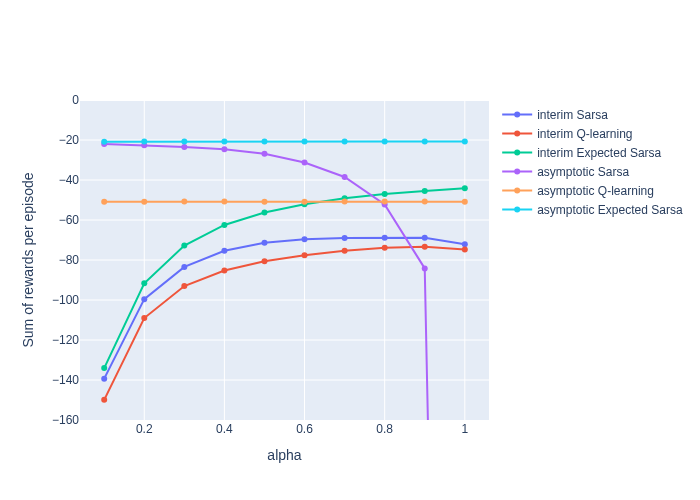

In [38]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=alphas, y=sarsaInterimCW, name="interim Sarsa"))
fig.add_trace(go.Scatter(x=alphas, y=qLearningInterimCW, name="interim Q-learning"))
fig.add_trace(go.Scatter(x=alphas, y=expectedSarsaInterimCW, name="interim Expected Sarsa"))
fig.add_trace(go.Scatter(x=alphas, y=sarsaAsymptoticCW, name="asymptotic Sarsa"))
fig.add_trace(go.Scatter(x=alphas, y=qLearningAsymptoticCW, name="asymptotic Q-learning"))
fig.add_trace(go.Scatter(x=alphas, y=expectedSarsaAsymptoticCW, name="asymptotic Expected Sarsa"))
fig.update_layout(xaxis_title="alpha", yaxis_title="Sum of rewards per episode", width=700)
fig.update_yaxes(range=[-160, 0])

# Maximization Bias Example

In [39]:
A, B = 0, 1
RIGHTMB, LEFTMB = 0, 1
bActions = np.arange(10)
def qLearningMB(nEpisodes, epsilon=0.1, alpha=0.5):
    QA = np.zeros(2)
    QB = np.zeros(len(bActions))
    leftAction = np.zeros(nEpisodes)

    for episode in range(nEpisodes):
        if QA[RIGHTMB] == QA[LEFTMB]:
            currentAction = np.random.choice([RIGHTMB, LEFTMB])
        else:
            greedyAction = np.argmax(QA)
            currentAction = greedyAction
            if np.random.random() < epsilon:
                currentAction = (greedyAction + 1) % 2

        if currentAction == RIGHTMB:
            QA[RIGHTMB] *= (1 - alpha)
        else:
            leftAction[episode] = 1
            QA[LEFTMB] += alpha * (np.max(QB) - QA[LEFTMB])
            if np.random.random() < epsilon:
                currentAction = np.random.choice(bActions)
            else:
                currentAction = np.random.choice([action for action in bActions if QB[action] == np.max(QB)])

            reward = np.random.normal(-0.1, 1)
            QB[currentAction] += alpha * (reward - QB[currentAction])

            
    return leftAction

In [40]:
def doubleQLearningMB(nEpisodes, epsilon=0.1, alpha=0.5):
    Q1A = np.zeros(2)
    Q1B = np.zeros(len(bActions))
    Q2A = np.zeros(2)
    Q2B = np.zeros(len(bActions))
    leftAction = np.zeros(nEpisodes)

    for episode in range(nEpisodes):
        if Q1A[RIGHTMB] + Q2A[RIGHTMB] == Q1A[LEFTMB] + Q2A[LEFTMB]:
            currentAction = np.random.choice([RIGHTMB, LEFTMB])
        else:
            greedyAction = np.argmax(Q1A + Q2A)
            currentAction = greedyAction
            if np.random.random() < epsilon:
                currentAction = (greedyAction + 1) % 2

        if currentAction == RIGHTMB:
            if np.random.random() < 0.5:
                Q1A[RIGHTMB] *= (1 - alpha)
            else:
                Q2A[RIGHTMB] *= (1 - alpha)
        else:
            leftAction[episode] = 1
            if np.random.random() < 0.5:
                bAction = np.random.choice([action for action in bActions if Q1B[action] == np.max(Q1B)])
                Q1A[LEFTMB] += alpha * (Q2B[bAction] - Q1A[LEFTMB])
            else:
                bAction = np.random.choice([action for action in bActions if Q2B[action] == np.max(Q2B)])
                Q2A[LEFTMB] += alpha * (Q1B[bAction] - Q2A[LEFTMB])

            if np.random.random() < epsilon:
                currentAction = np.random.choice(bActions)
            else:
                currentAction = np.random.choice([action for action in bActions if Q1B[action] + Q2B[action] == np.max(Q1B + Q2B)])

            reward = np.random.normal(-0.1, 1)
            if np.random.random() < 0.5:
                Q1B[currentAction] += alpha * (reward - Q1B[currentAction])
            else:
                Q2B[currentAction] += alpha * (reward - Q2B[currentAction])
            
    return leftAction

In [41]:
leftActionsQLearning = []
leftActionsDoubleQLearning = []
for run in range(10000):
    leftActionsQLearning.append(qLearningMB(300, 0.1, 0.1))
    leftActionsDoubleQLearning.append(doubleQLearningMB(300, 0.1, 0.1))

avgLeftActionsQLearning = 100 * np.mean(leftActionsQLearning, axis=0)
avgLeftActionsDoubleQLearning = 100 * np.mean(leftActionsDoubleQLearning, axis=0)

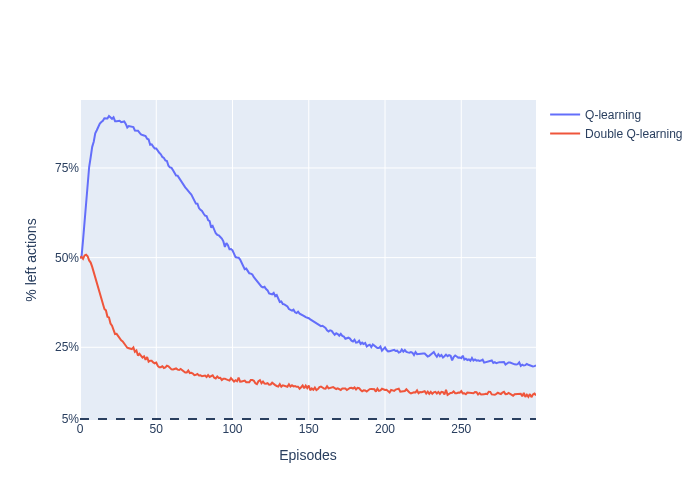

In [42]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=avgLeftActionsQLearning, name="Q-learning"))
fig.add_trace(go.Scatter(y=avgLeftActionsDoubleQLearning, name="Double Q-learning"))
fig.add_hline(y=5, line=dict(dash="dash"))
fig.update_yaxes(tickvals=[0, 5, 25, 50, 75, 100], ticktext=["0%", "5%", "25%", "50%", "75%", "100%"])
fig.update_layout(width=700, xaxis_title="Episodes", yaxis_title="% left actions")